In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [ ]:
DEFAULT_PARAMS = dict(
    C_m=1.0,     # membrane capacitance      (uF/cm^2)
    G_Na=120.0,  # max Na+ conductance       (mS/cm^2)
    G_K=36.0,    # max K+ conductance        (mS/cm^2)
    G_L=0.3,     # leak conductance          (mS/cm^2)
    E_Na=50.0,   # Na+ reversal potential    (mV)
    E_K=-77.0,   # K+ reversal potential     (mV)
    E_L=-54.4,   # leak reversal potential   (mV)
    V0=-65.0,    # resting potential         (mV)
    m0=0.05, h0=0.60, n0=0.32,  # gates at rest
)

In [ ]:
def alpha_m(V): return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
def beta_m(V):  return 4.0 * np.exp(-(V + 65) / 18)
def alpha_h(V): return 0.07 * np.exp(-(V + 65) / 20)
def beta_h(V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))
def alpha_n(V): return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
def beta_n(V):  return 0.125 * np.exp(-(V + 65) / 80)

def x_inf(a, b): return a / (a + b)
def tau_x(a, b): return 1.0 / (a + b)

In [ ]:
def dVdt(V, m, h, n, I_ext, p):
    I_Na = p['G_Na'] * m**3 * h * (V - p['E_Na'])
    I_K  = p['G_K']  * n**4     * (V - p['E_K'])
    I_L  = p['G_L']              * (V - p['E_L'])
    return (I_ext - I_Na - I_K - I_L) / p['C_m']

def dmdt(V, m):
    a, b = alpha_m(V), beta_m(V)
    return (x_inf(a, b) - m) / tau_x(a, b)

def dhdt(V, h):
    a, b = alpha_h(V), beta_h(V)
    return (x_inf(a, b) - h) / tau_x(a, b)

def dndt(V, n):
    a, b = alpha_n(V), beta_n(V)
    return (x_inf(a, b) - n) / tau_x(a, b)

In [ ]:
def simulate_hh(I_ext, T=150, dt=0.02, params=None):
    """
    I_ext  : injected current (uA/cm^2), constant over the run
    T      : total simulated time (ms)
    dt     : timestep (ms)
    params : dict overriding any key in DEFAULT_PARAMS, e.g. {'G_Na': 80}
    Returns: t, V, m, h, n, spike_times
    """
    p = {**DEFAULT_PARAMS, **(params or {})}
    t = np.arange(0, T, dt)
    V = np.full(len(t), p['V0'])
    m = np.full(len(t), p['m0'])
    h = np.full(len(t), p['h0'])
    n = np.full(len(t), p['n0'])
    spike_times = []
    above = False

    for i in range(1, len(t)):
        Vi, mi, hi, ni = V[i-1], m[i-1], h[i-1], n[i-1]
        V[i] = Vi + dVdt(Vi, mi, hi, ni, I_ext, p) * dt
        m[i] = mi + dmdt(Vi, mi) * dt
        h[i] = hi + dhdt(Vi, hi) * dt
        n[i] = ni + dndt(Vi, ni) * dt

        if V[i] >= 0 and not above:
            spike_times.append(t[i])
            above = True
        elif V[i] < -10:
            above = False

    return t, V, m, h, n, spike_times

In [ ]:
t, V, m, h, n, sp = simulate_hh(I_ext=0, T=50)
print(f"I_ext=0: resting V settles to {V[-1]:.2f} mV (expected ~ -65 mV), "
      f"spikes = {len(sp)} (expected 0)")

I_ext=0: resting V settles to -65.00 mV (expected ~ -65 mV), spikes = 0 (expected 0)


In [ ]:
def extract_spike_features(t, V, spike_times, dt):
    n_spikes = len(spike_times)
    duration_s = (t[-1] - t[0]) / 1000.0

    features = dict(
        n_spikes=n_spikes,
        firing_rate_hz=n_spikes / duration_s if duration_s > 0 else 0.0,
        mean_isi_ms=np.nan, cv_isi=np.nan,
        mean_amplitude_mv=np.nan, mean_apd50_ms=np.nan,
        max_dvdt=np.nan, threshold_mv=np.nan,
    )
    if n_spikes == 0:
        return features

    if n_spikes >= 2:
        isis = np.diff(spike_times)
        features['mean_isi_ms'] = float(np.mean(isis))
        features['cv_isi'] = float(np.std(isis) / np.mean(isis)) if np.mean(isis) > 0 else np.nan

    features['max_dvdt'] = float(np.max(np.gradient(V, t)))

    amplitudes, widths, thresholds = [], [], []
    pre_ms, post_ms = 5, 5  # narrow window: brackets ONE spike, not neighbors
    for st in spike_times:
        idx = np.argmin(np.abs(t - st))
        lo = max(0, idx - int(pre_ms / dt))
        hi = min(len(t), idx + int(post_ms / dt))
        Vw, tw = V[lo:hi], t[lo:hi]
        if len(Vw) < 3:
            continue

        peak_i = int(np.argmax(Vw))
        v_peak = Vw[peak_i]
        v_rest = Vw[0]
        amplitude = v_peak - v_rest
        amplitudes.append(amplitude)

        half = v_rest + amplitude / 2
        left = peak_i
        while left > 0 and Vw[left] >= half:
            left -= 1
        right = peak_i
        while right < len(Vw) - 1 and Vw[right] >= half:
            right += 1
        if right > left:
            widths.append(tw[right] - tw[left])

        if peak_i > 1:
            seg_dvdt = np.gradient(Vw[:peak_i+1], tw[:peak_i+1])
            rising = np.where(seg_dvdt > 5)[0]
            if len(rising):
                thresholds.append(Vw[rising[0]])

    if amplitudes: features['mean_amplitude_mv'] = float(np.mean(amplitudes))
    if widths:     features['mean_apd50_ms'] = float(np.mean(widths))
    if thresholds: features['threshold_mv'] = float(np.mean(thresholds))

    return features

In [ ]:
def find_rheobase(params=None, I_min=0.0, I_max=40.0, tol=0.25, T=150, dt=0.02):
    def fires(I):
        _, _, _, _, _, sp = simulate_hh(I, T=T, dt=dt, params=params)
        return len(sp) > 0

    lo, hi = I_min, I_max
    if fires(lo):
        return float(lo)
    if not fires(hi):
        return np.nan

    while hi - lo > tol:
        mid = (lo + hi) / 2
        if fires(mid):
            hi = mid
        else:
            lo = mid
    return float(hi)

In [ ]:
t, V, m, h, n, sp = simulate_hh(I_ext=10, T=100)
feats = extract_spike_features(t, V, sp, dt=0.02)
for k, v in feats.items():
    print(f"{k:20s}: {v:.3f}" if isinstance(v, float) else f"{k:20s}: {v}")

rheo = find_rheobase()
print(f"\n{'rheobase (uA/cm^2)':20s}: {rheo:.3f}")

n_spikes            : 7
firing_rate_hz      : 70.014
mean_isi_ms         : 14.680
cv_isi              : 0.007
mean_amplitude_mv   : 95.653
mean_apd50_ms       : 1.354
max_dvdt            : 305.399
threshold_mv        : -55.814

rheobase (uA/cm^2)  : 2.344


/tmp/ipykernel_975/3768110150.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


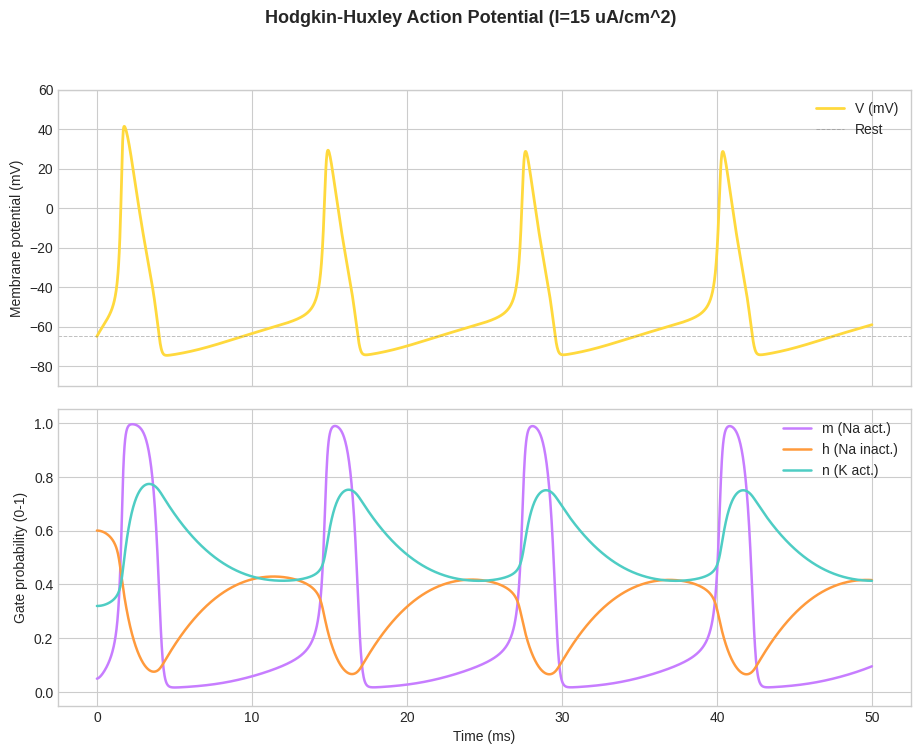

In [ ]:
def plot_action_potential(I_ext=15, T=50, params=None):
    t, V, m, h, n, spikes = simulate_hh(I_ext, T, params=params)

    fig = plt.figure(figsize=(11, 8))
    gs = GridSpec(2, 1, hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    ax1.plot(t, V, color='#ffd93d', lw=2, label='V (mV)')
    ax1.axhline(-65, color='gray', ls='--', lw=0.7, alpha=0.5, label='Rest')
    ax1.set_ylabel('Membrane potential (mV)'); ax1.set_ylim(-90, 60)
    ax1.legend(loc='upper right')
    plt.setp(ax1.get_xticklabels(), visible=False)

    ax2.plot(t, m, color='#c77dff', lw=1.8, label='m (Na act.)')
    ax2.plot(t, h, color='#ff9a3c', lw=1.8, label='h (Na inact.)')
    ax2.plot(t, n, color='#4ecdc4', lw=1.8, label='n (K act.)')
    ax2.set_ylabel('Gate probability (0-1)'); ax2.set_xlabel('Time (ms)')
    ax2.set_ylim(-0.05, 1.05); ax2.legend(loc='upper right')

    fig.suptitle(f'Hodgkin-Huxley Action Potential (I={I_ext} uA/cm^2)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_action_potential(I_ext=15)

/tmp/ipykernel_975/1710492232.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


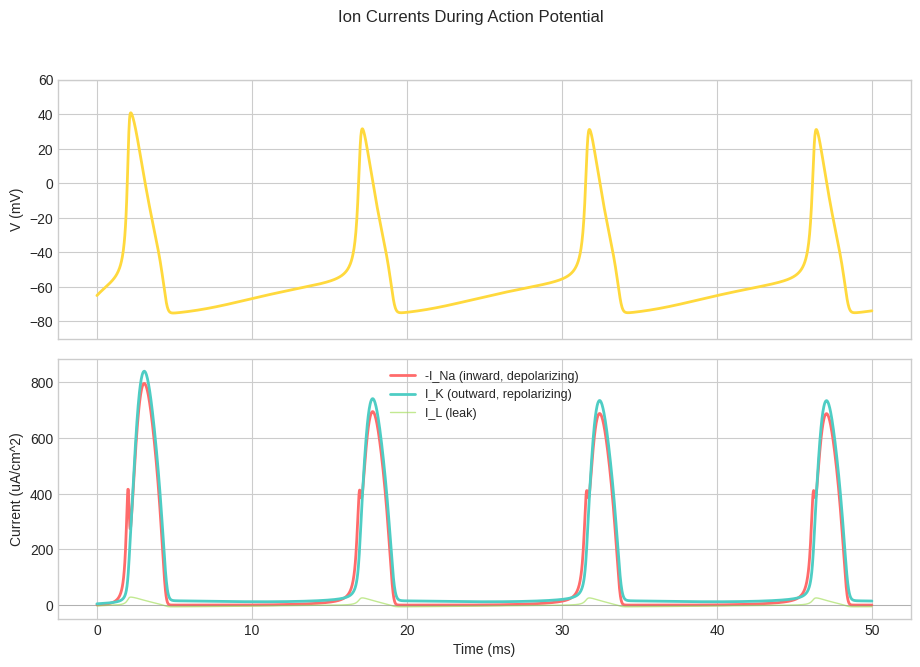

In [ ]:
def plot_ion_currents(I_ext=10, T=50, params=None):
    p = {**DEFAULT_PARAMS, **(params or {})}
    t, V, m, h, n, _ = simulate_hh(I_ext, T, params=params)
    I_Na = p['G_Na'] * m**3 * h * (V - p['E_Na'])
    I_K  = p['G_K']  * n**4     * (V - p['E_K'])
    I_L  = p['G_L']              * (V - p['E_L'])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                    gridspec_kw={'hspace': 0.08})
    ax1.plot(t, V, color='#ffd93d', lw=2)
    ax1.set_ylabel('V (mV)'); ax1.set_ylim(-90, 60)
    plt.setp(ax1.get_xticklabels(), visible=False)

    ax2.plot(t, -I_Na, color='#ff6b6b', lw=2, label='-I_Na (inward, depolarizing)')
    ax2.plot(t, I_K, color='#4ecdc4', lw=2, label='I_K (outward, repolarizing)')
    ax2.plot(t, I_L, color='#a8e063', lw=1, label='I_L (leak)', alpha=0.7)
    ax2.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax2.set_ylabel('Current (uA/cm^2)'); ax2.set_xlabel('Time (ms)')
    ax2.legend(fontsize=9)

    plt.suptitle('Ion Currents During Action Potential')
    plt.tight_layout(); plt.show()

plot_ion_currents()

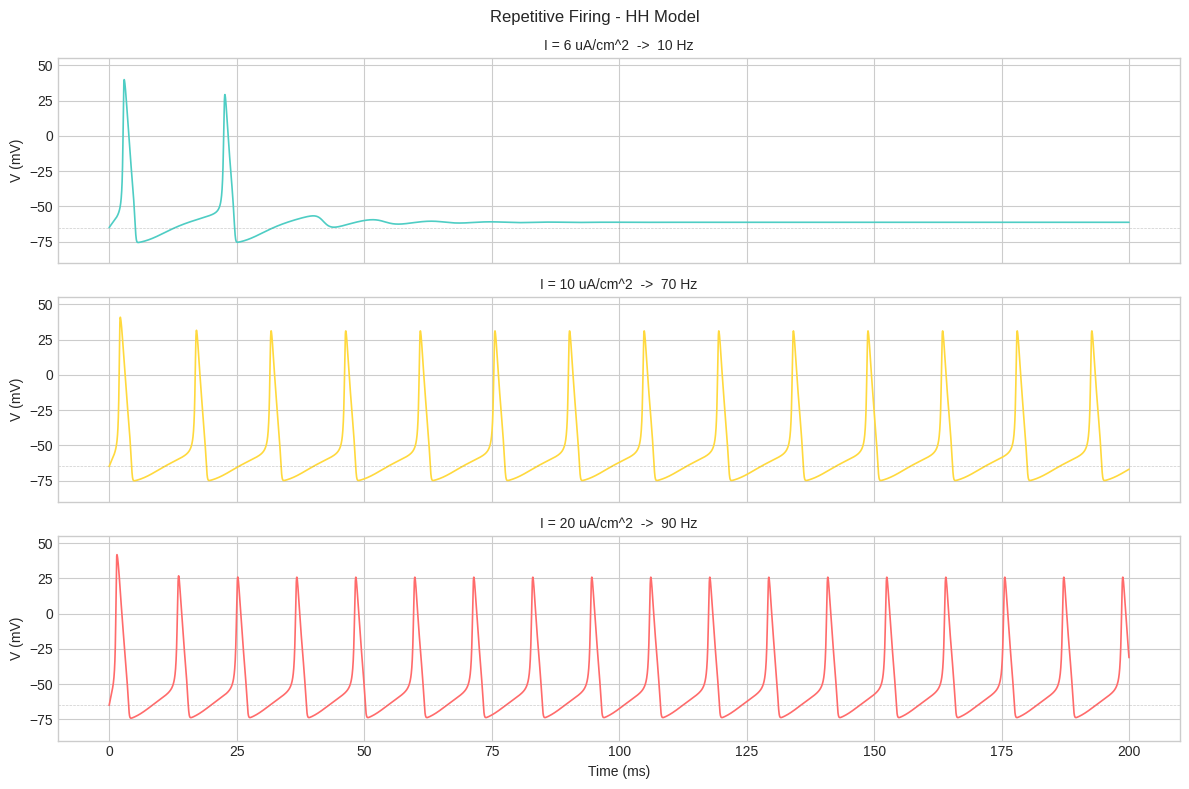

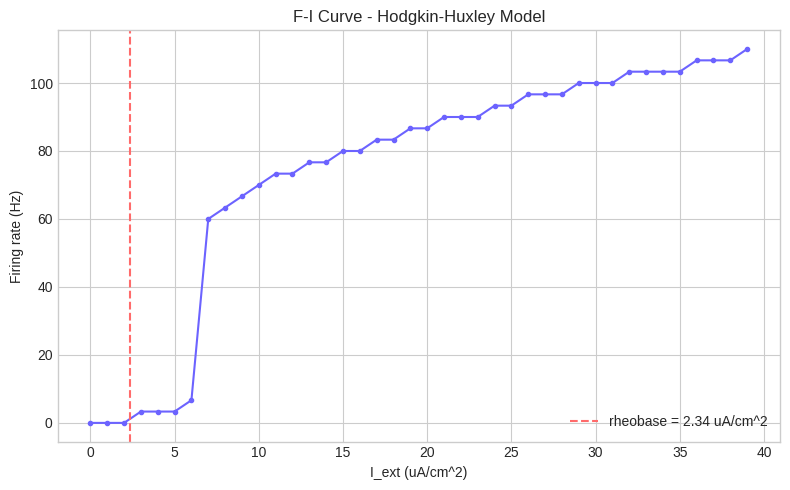

In [ ]:
def plot_repetitive_firing(params=None):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    currents = [6, 10, 20]
    colors = ['#4ecdc4', '#ffd93d', '#ff6b6b']

    for ax, I, col in zip(axes, currents, colors):
        t, V, _, _, _, sp = simulate_hh(I, T=200, params=params)
        ax.plot(t, V, color=col, lw=1.2)
        ax.axhline(-65, color='gray', lw=0.5, ls='--', alpha=0.4)
        ax.set_ylabel('V (mV)'); ax.set_ylim(-90, 55)
        rate = len(sp) / 0.2
        ax.set_title(f'I = {I} uA/cm^2  ->  {rate:.0f} Hz', fontsize=10)

    axes[-1].set_xlabel('Time (ms)')
    plt.suptitle('Repetitive Firing - HH Model')
    plt.tight_layout(); plt.show()


def plot_fi_curve(params=None):
    I_vals = np.arange(0, 40, 1.0)
    rates = []
    for I in I_vals:
        _, _, _, _, _, sp = simulate_hh(I, T=300, params=params)
        rates.append(len(sp) / 0.3)

    rheo = find_rheobase(params=params)

    plt.figure(figsize=(8, 5))
    plt.plot(I_vals, rates, 'o-', color='#6c63ff', ms=3, lw=1.5)
    if not np.isnan(rheo):
        plt.axvline(rheo, color='#ff6b6b', ls='--', lw=1.5,
                    label=f'rheobase = {rheo:.2f} uA/cm^2')
        plt.legend()
    plt.xlabel('I_ext (uA/cm^2)'); plt.ylabel('Firing rate (Hz)')
    plt.title('F-I Curve - Hodgkin-Huxley Model')
    plt.tight_layout(); plt.show()
    return I_vals, np.array(rates), rheo

plot_repetitive_firing()
_ = plot_fi_curve()

In [ ]:
def sweep_1d(param_name, values, I_ext=10, T=200, dt=0.02, base_params=None):
    base_params = base_params or {}
    results = {k: [] for k in
               ['firing_rate_hz', 'mean_amplitude_mv', 'mean_apd50_ms',
                'threshold_mv', 'rheobase']}

    for val in values:
        p = {**base_params, param_name: val}
        t, V, m, h, n, sp = simulate_hh(I_ext, T=T, dt=dt, params=p)
        feats = extract_spike_features(t, V, sp, dt)
        for k in ['firing_rate_hz', 'mean_amplitude_mv', 'mean_apd50_ms', 'threshold_mv']:
            results[k].append(feats[k])
        results['rheobase'].append(find_rheobase(params=p, T=120, dt=dt, tol=0.5))

    return {k: np.array(v) for k, v in results.items()}

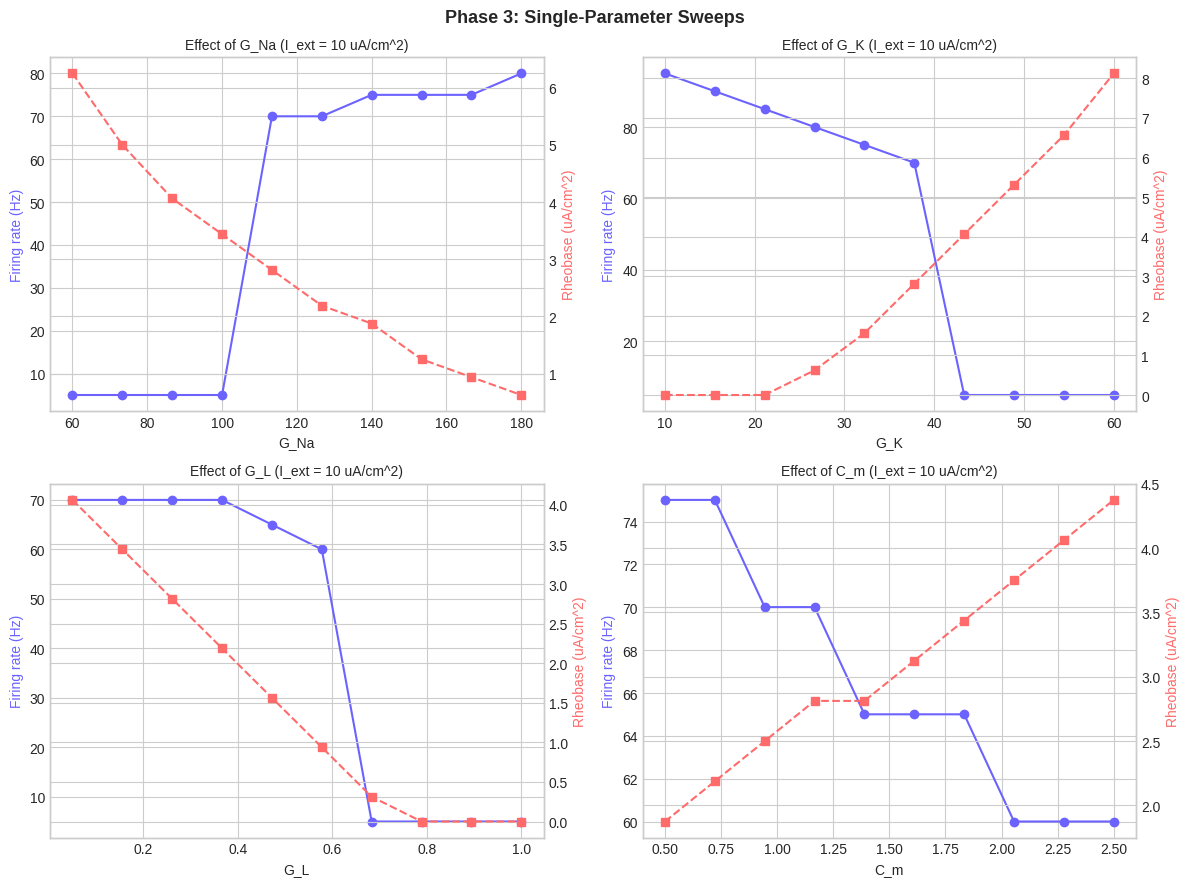

In [ ]:
sweep_configs = {
    'G_Na': np.linspace(60, 180, 10),
    'G_K':  np.linspace(10, 60, 10),
    'G_L':  np.linspace(0.05, 1.0, 10),
    'C_m':  np.linspace(0.5, 2.5, 10),
}

sweep_results = {name: sweep_1d(name, vals) for name, vals in sweep_configs.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, vals) in zip(axes.flat, sweep_configs.items()):
    res = sweep_results[name]
    ax2 = ax.twinx()
    ax.plot(vals, res['firing_rate_hz'], 'o-', color='#6c63ff', label='firing rate')
    ax2.plot(vals, res['rheobase'], 's--', color='#ff6b6b', label='rheobase')
    ax.set_xlabel(name); ax.set_ylabel('Firing rate (Hz)', color='#6c63ff')
    ax2.set_ylabel('Rheobase (uA/cm^2)', color='#ff6b6b')
    ax.set_title(f'Effect of {name} (I_ext = 10 uA/cm^2)', fontsize=10)

fig.suptitle('Phase 3: Single-Parameter Sweeps', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
def excitability_map(param_x, x_values, param_y, y_values,
                      I_ext=10, T=150, dt=0.02, base_params=None):
    base_params = base_params or {}
    fr_grid = np.zeros((len(y_values), len(x_values)))
    rheo_grid = np.zeros((len(y_values), len(x_values)))

    for iy, yv in enumerate(y_values):
        for ix, xv in enumerate(x_values):
            p = {**base_params, param_x: xv, param_y: yv}
            t, V, m, h, n, sp = simulate_hh(I_ext, T=T, dt=dt, params=p)
            feats = extract_spike_features(t, V, sp, dt)
            fr_grid[iy, ix] = feats['firing_rate_hz']
            rheo_grid[iy, ix] = find_rheobase(params=p, T=120, dt=dt, tol=0.5)

    return fr_grid, rheo_grid

/tmp/ipykernel_975/3825185094.py:1: RuntimeWarning: invalid value encountered in scalar divide
  def alpha_m(V): return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))


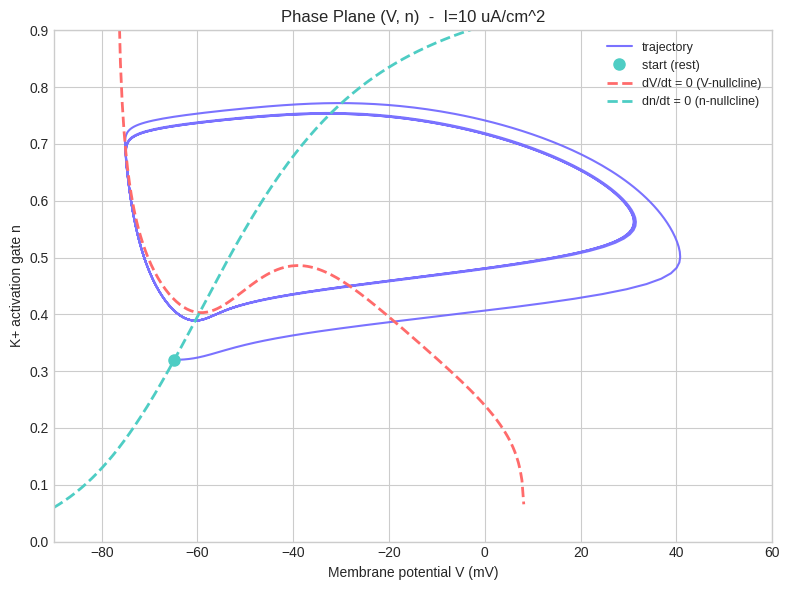

In [ ]:
def plot_phase_plane(I_ext=10, params=None):
    p = {**DEFAULT_PARAMS, **(params or {})}
    t, V, m, h, n, _ = simulate_hh(I_ext, T=60, params=params)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.plot(V, n, color='#6c63ff', lw=1.5, alpha=0.9, label='trajectory')
    ax.plot(V[0], n[0], 'o', color='#4ecdc4', ms=8, label='start (rest)')

    V_range = np.linspace(-90, 60, 400)
    m_inf = np.array([x_inf(alpha_m(v), beta_m(v)) for v in V_range])
    h_inf = np.array([x_inf(alpha_h(v), beta_h(v)) for v in V_range])
    I_rest = I_ext - p['G_Na'] * m_inf**3 * h_inf * (V_range - p['E_Na']) - p['G_L'] * (V_range - p['E_L'])
    with np.errstate(invalid='ignore'):
        n_Vnull = (I_rest / p['G_K'] / (V_range - p['E_K'])) ** (1/4)
    mask = (n_Vnull > 0) & (n_Vnull < 1)
    ax.plot(V_range[mask], n_Vnull[mask], color='#ff6b6b', lw=2, ls='--',
            label='dV/dt = 0 (V-nullcline)')

    n_inf = np.array([x_inf(alpha_n(v), beta_n(v)) for v in V_range])
    ax.plot(V_range, n_inf, color='#4ecdc4', lw=2, ls='--',
            label='dn/dt = 0 (n-nullcline)')

    ax.set_xlabel('Membrane potential V (mV)'); ax.set_ylabel('K+ activation gate n')
    ax.set_xlim(-90, 60); ax.set_ylim(0, 0.9); ax.legend(fontsize=9)
    ax.set_title(f'Phase Plane (V, n)  -  I={I_ext} uA/cm^2')
    plt.tight_layout(); plt.show()

plot_phase_plane(I_ext=10)

In [ ]:
def simulate_hh_noisy(I0, sigma, T=300, dt=0.02, params=None, seed=None):
    rng = np.random.default_rng(seed)
    p = {**DEFAULT_PARAMS, **(params or {})}
    t = np.arange(0, T, dt)
    V = np.full(len(t), p['V0'])
    m = np.full(len(t), p['m0'])
    h = np.full(len(t), p['h0'])
    n = np.full(len(t), p['n0'])
    spike_times = []
    above = False
    noise = rng.normal(0, 1, size=len(t))

    for i in range(1, len(t)):
        Vi, mi, hi, ni = V[i-1], m[i-1], h[i-1], n[i-1]
        I_t = I0 + sigma * noise[i]
        V[i] = Vi + dVdt(Vi, mi, hi, ni, I_t, p) * dt
        m[i] = mi + dmdt(Vi, mi) * dt
        h[i] = hi + dhdt(Vi, hi) * dt
        n[i] = ni + dndt(Vi, ni) * dt

        if V[i] >= 0 and not above:
            spike_times.append(t[i])
            above = True
        elif V[i] < -10:
            above = False

    return t, V, spike_times

In [ ]:
def noise_robustness_sweep(I0, sigma_values, n_trials=8, T=300, dt=0.02, params=None):
    results = {'firing_rate_mean': [], 'firing_rate_std': [], 'cv_isi_mean': []}
    for sigma in sigma_values:
        rates, cvs = [], []
        for trial in range(n_trials):
            t, V, sp = simulate_hh_noisy(I0, sigma, T=T, dt=dt, params=params, seed=trial)
            rates.append(len(sp) / (T / 1000))
            if len(sp) >= 3:
                isis = np.diff(sp)
                cvs.append(np.std(isis) / np.mean(isis))
        results['firing_rate_mean'].append(np.mean(rates))
        results['firing_rate_std'].append(np.std(rates))
        results['cv_isi_mean'].append(np.mean(cvs) if cvs else np.nan)
    return {k: np.array(v) for k, v in results.items()}

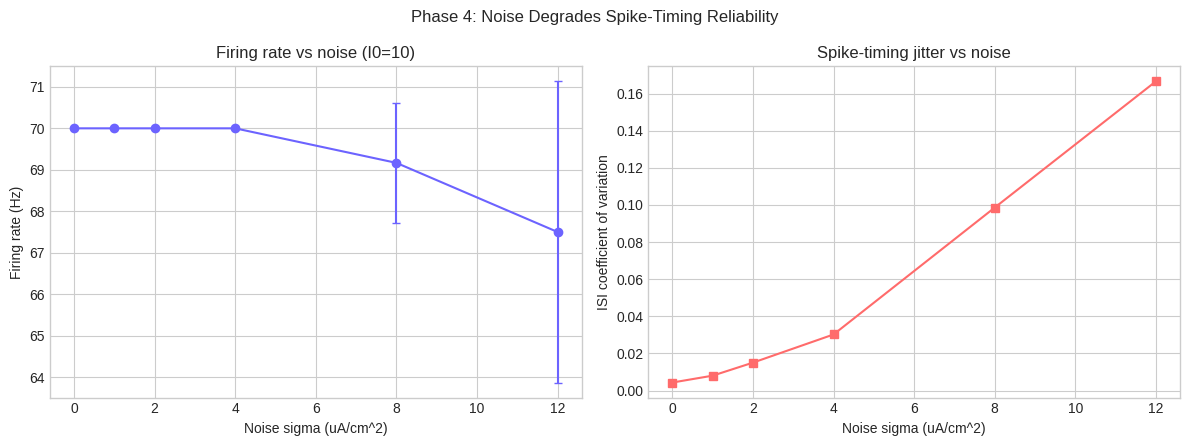

In [ ]:
sigma_values = [0, 1, 2, 4, 8, 12]
I0_supra = 10
res_supra = noise_robustness_sweep(I0_supra, sigma_values, n_trials=8, T=300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.errorbar(sigma_values, res_supra['firing_rate_mean'], yerr=res_supra['firing_rate_std'],
             fmt='o-', color='#6c63ff', capsize=3)
ax1.set_xlabel('Noise sigma (uA/cm^2)'); ax1.set_ylabel('Firing rate (Hz)')
ax1.set_title(f'Firing rate vs noise (I0={I0_supra})')

ax2.plot(sigma_values, res_supra['cv_isi_mean'], 's-', color='#ff6b6b')
ax2.set_xlabel('Noise sigma (uA/cm^2)'); ax2.set_ylabel('ISI coefficient of variation')
ax2.set_title('Spike-timing jitter vs noise')

plt.suptitle('Phase 4: Noise Degrades Spike-Timing Reliability')
plt.tight_layout(); plt.show()

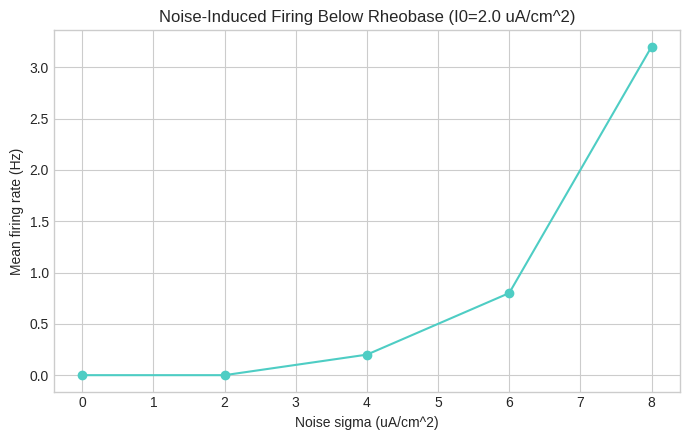

In [ ]:
I0_sub = 2.0
sub_sigmas = [0, 2, 4, 6, 8]
sub_rates = []
for sigma in sub_sigmas:
    trial_rates = [len(simulate_hh_noisy(I0_sub, sigma, T=500, dt=0.02, seed=k)[2]) / 0.5
                   for k in range(10)]
    sub_rates.append(np.mean(trial_rates))

plt.figure(figsize=(7, 4.5))
plt.plot(sub_sigmas, sub_rates, 'o-', color='#4ecdc4')
plt.xlabel('Noise sigma (uA/cm^2)'); plt.ylabel('Mean firing rate (Hz)')
plt.title(f'Noise-Induced Firing Below Rheobase (I0={I0_sub} uA/cm^2)')
plt.tight_layout(); plt.show()

In [ ]:
def bifurcation_scan(I_values, T=600, transient=300, dt=0.02, params=None):
    v_min, v_max, rates = [], [], []
    for I in I_values:
        t, V, m, h, n, sp = simulate_hh(I, T=T, dt=dt, params=params)
        mask = t >= transient
        Vss = V[mask]
        v_min.append(np.min(Vss))
        v_max.append(np.max(Vss))
        steady_spikes = [s for s in sp if s >= transient]
        rates.append(len(steady_spikes) / ((T - transient) / 1000))
    return np.array(v_min), np.array(v_max), np.array(rates)

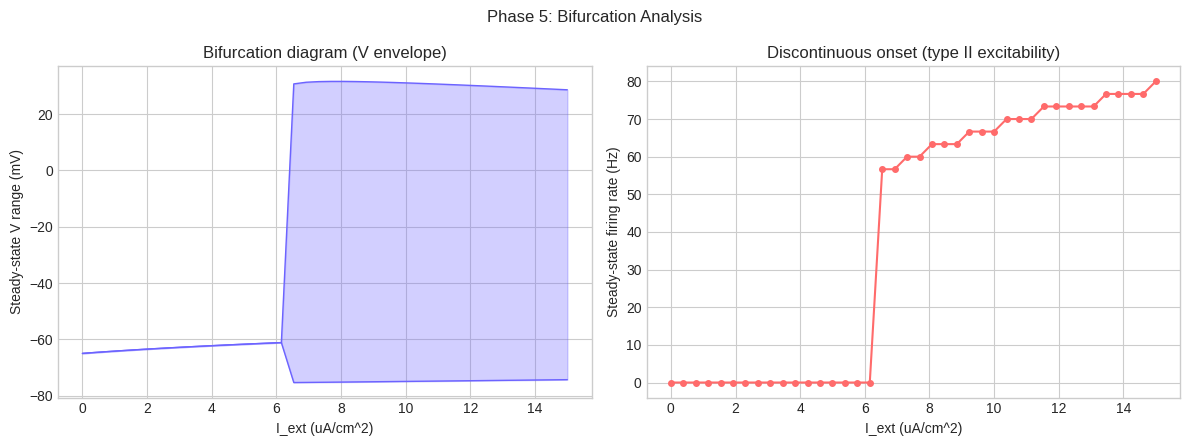

Firing jumps from 0.0 Hz to 56.7 Hz between I=6.15 and I=6.54 uA/cm^2 -- consistent with a subcritical Hopf bifurcation.


In [ ]:
I_vals = np.linspace(0, 15, 40)
vmin, vmax, rates = bifurcation_scan(I_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.fill_between(I_vals, vmin, vmax, color='#6c63ff', alpha=0.3)
ax1.plot(I_vals, vmin, color='#6c63ff', lw=1)
ax1.plot(I_vals, vmax, color='#6c63ff', lw=1)
ax1.set_xlabel('I_ext (uA/cm^2)'); ax1.set_ylabel('Steady-state V range (mV)')
ax1.set_title('Bifurcation diagram (V envelope)')

ax2.plot(I_vals, rates, 'o-', color='#ff6b6b', ms=4)
ax2.set_xlabel('I_ext (uA/cm^2)'); ax2.set_ylabel('Steady-state firing rate (Hz)')
ax2.set_title('Discontinuous onset (type II excitability)')

plt.suptitle('Phase 5: Bifurcation Analysis')
plt.tight_layout(); plt.show()

jump_idx = np.argmax(np.diff(rates) > 20)
print(f"Firing jumps from {rates[jump_idx]:.1f} Hz to {rates[jump_idx+1]:.1f} Hz "
      f"between I={I_vals[jump_idx]:.2f} and I={I_vals[jump_idx+1]:.2f} uA/cm^2 "
      f"-- consistent with a subcritical Hopf bifurcation.")

In [ ]:
def classify_phenotype(rate):
    if rate == 0:
        return 'silent'
    elif rate < 40:
        return 'low-rate'
    else:
        return 'high-rate'

def generate_phenotype_dataset(n_samples=400, I_ext=10, T=150, dt=0.02, seed=0):
    rng = np.random.default_rng(seed)
    G_Na_range = (40, 200)
    G_K_range  = (5, 70)
    G_L_range  = (0.05, 1.2)
    C_m_range  = (0.5, 3.0)

    X, y = [], []
    for _ in range(n_samples):
        p = dict(
            G_Na=rng.uniform(*G_Na_range), G_K=rng.uniform(*G_K_range),
            G_L=rng.uniform(*G_L_range), C_m=rng.uniform(*C_m_range),
        )
        t, V, m, h, n, sp = simulate_hh(I_ext, T=T, dt=dt, params=p)
        rate = len(sp) / (T / 1000)
        X.append([p['G_Na'], p['G_K'], p['G_L'], p['C_m']])
        y.append(classify_phenotype(rate))

    return np.array(X), np.array(y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X, y = generate_phenotype_dataset(n_samples=400)
print("Class counts:", {c: int((y == c).sum()) for c in set(y)})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)

clf = RandomForestClassifier(n_estimators=200, random_state=0)
clf.fit(X_train, y_train)
print(classification_report(y_test, clf.predict(X_test)))

Class counts: {np.str_('high-rate'): 186, np.str_('silent'): 67, np.str_('low-rate'): 147}
              precision    recall  f1-score   support

   high-rate       0.96      0.96      0.96        46
    low-rate       0.87      0.92      0.89        37
      silent       0.93      0.82      0.88        17

    accuracy                           0.92       100
   macro avg       0.92      0.90      0.91       100
weighted avg       0.92      0.92      0.92       100



In [ ]:
def convergence_check(dt_values, I_ext=10, T=100):
    results = []
    for dt in dt_values:
        t, V, m, h, n, sp = simulate_hh(I_ext, T=T, dt=dt)
        rate = len(sp) / (T / 1000)
        first_spike = sp[0] if sp else np.nan
        results.append((dt, rate, first_spike))
    return results

conv = convergence_check([0.1, 0.05, 0.02, 0.01, 0.005])
print(f"{'dt (ms)':>8s}  {'rate (Hz)':>10s}  {'1st spike (ms)':>15s}")
for dt, rate, fs in conv:
    print(f"{dt:8.3f}  {rate:10.2f}  {fs:15.2f}")
print("\ndt=0.1 clearly disagrees with the finer steps -- it's numerically"
      " unstable here. dt <= 0.02 has converged.")

/tmp/ipykernel_975/3825185094.py:1: RuntimeWarning: overflow encountered in exp
  def alpha_m(V): return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
/tmp/ipykernel_975/3825185094.py:2: RuntimeWarning: overflow encountered in exp
  def beta_m(V):  return 4.0 * np.exp(-(V + 65) / 18)
/tmp/ipykernel_975/1496381707.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  return (x_inf(a, b) - m) / tau_x(a, b)
/tmp/ipykernel_975/3825185094.py:3: RuntimeWarning: overflow encountered in exp
  def alpha_h(V): return 0.07 * np.exp(-(V + 65) / 20)
/tmp/ipykernel_975/3825185094.py:4: RuntimeWarning: overflow encountered in exp
  def beta_h(V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))
/tmp/ipykernel_975/3825185094.py:8: RuntimeWarning: invalid value encountered in scalar divide
  def x_inf(a, b): return a / (a + b)
/tmp/ipykernel_975/3825185094.py:5: RuntimeWarning: overflow encountered in exp
  def alpha_n(V): return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
/tmp/ipykernel_975

 dt (ms)   rate (Hz)   1st spike (ms)
   0.100       30.00             2.10
   0.050       70.00             2.05
   0.020       70.00             1.96
   0.010       70.00             1.95
   0.005       70.00             1.94

dt=0.1 clearly disagrees with the finer steps -- it's numerically unstable here. dt <= 0.02 has converged.


In [ ]:
def current_dominance_check(I_ext=10, T=50, dt=0.02):
    p = DEFAULT_PARAMS
    t, V, m, h, n, sp = simulate_hh(I_ext, T=T, dt=dt)
    g_Na = p['G_Na'] * m**3 * h
    g_K  = p['G_K']  * n**4
    if not sp:
        return None
    idx = np.argmin(np.abs(t - sp[0]))
    lo, hi = max(0, idx - 250), min(len(t), idx + 250)
    t_Na_peak = t[lo:hi][np.argmax(g_Na[lo:hi])]
    t_K_peak  = t[lo:hi][np.argmax(g_K[lo:hi])]
    return dict(t_Na_peak=t_Na_peak, t_K_peak=t_K_peak,
                Na_before_K=bool(t_Na_peak < t_K_peak),
                delay_ms=float(t_K_peak - t_Na_peak))

dom = current_dominance_check()
print(dom)
assert dom['Na_before_K'], "Expected Na conductance to peak before K conductance"
print(f"\nConfirmed: g_Na peaks {dom['delay_ms']:.2f} ms before g_K "
      "-- matches the textbook Na-then-K sequence underlying the action potential.")

{'t_Na_peak': np.float64(2.3000000000000003), 't_K_peak': np.float64(3.7600000000000002), 'Na_before_K': True, 'delay_ms': 1.46}

Confirmed: g_Na peaks 1.46 ms before g_K -- matches the textbook Na-then-K sequence underlying the action potential.


/tmp/ipykernel_975/851528465.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


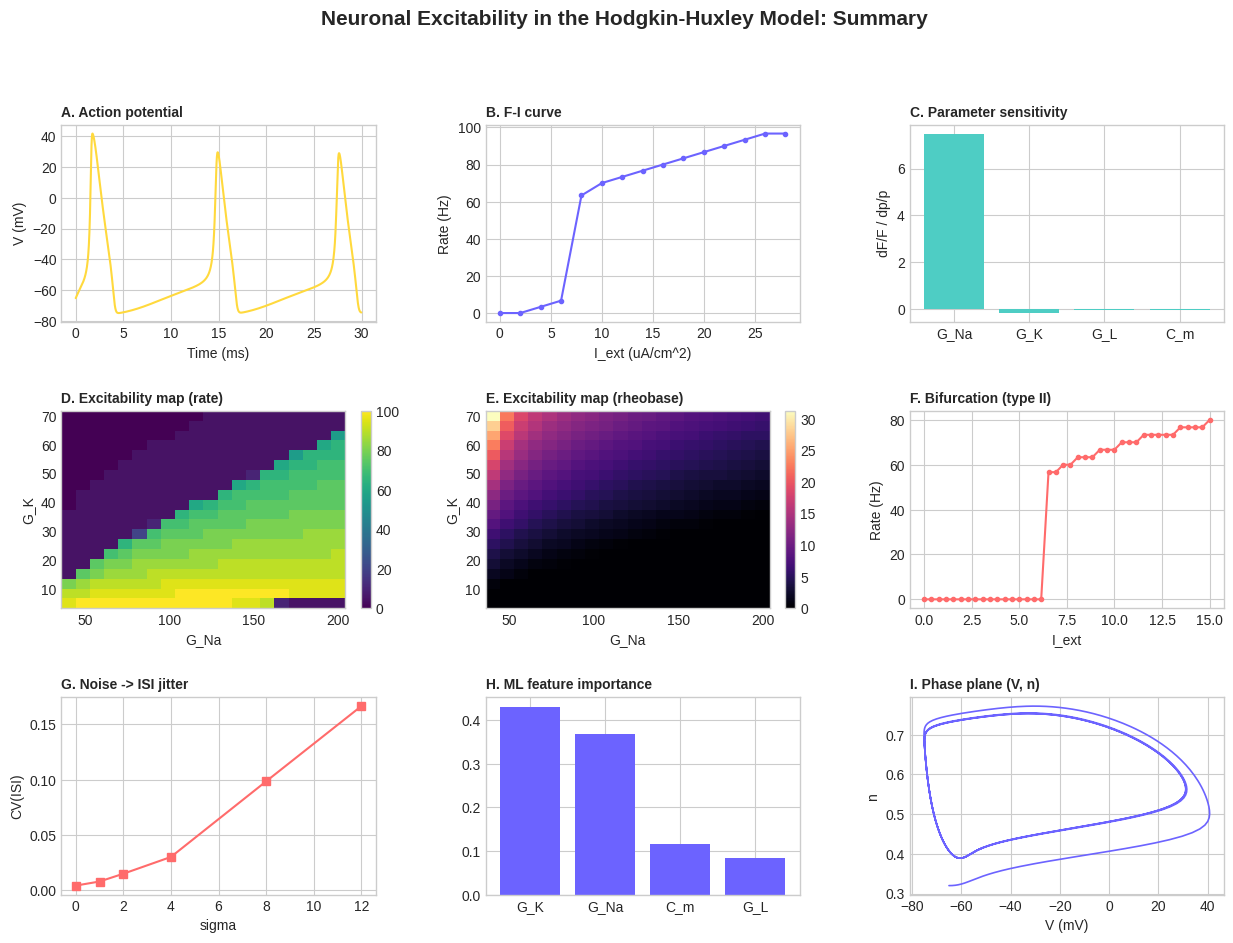

In [ ]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
t, V, m, h, n, _ = simulate_hh(15, T=30)
ax.plot(t, V, color='#ffd93d', lw=1.5)
ax.set_title('A. Action potential', fontsize=10, loc='left', fontweight='bold')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('V (mV)')

ax = fig.add_subplot(gs[0, 1])
I_vals_fi = np.arange(0, 30, 2)
rates_fi = [len(simulate_hh(I, T=300)[5]) / 0.3 for I in I_vals_fi]
ax.plot(I_vals_fi, rates_fi, 'o-', color='#6c63ff', ms=3)
ax.set_title('B. F-I curve', fontsize=10, loc='left', fontweight='bold')
ax.set_xlabel('I_ext (uA/cm^2)'); ax.set_ylabel('Rate (Hz)')

ax = fig.add_subplot(gs[0, 2])
names = list(sweep_configs.keys())
sens = []
for name, vals in sweep_configs.items():
    fr = sweep_results[name]['firing_rate_hz']
    valid = fr > 0
    if valid.sum() >= 2 and fr[valid][0] > 0 and vals[valid][0] > 0:
        p_lo, p_hi = vals[valid][0], vals[valid][-1]
        f_lo, f_hi = fr[valid][0], fr[valid][-1]
        sens.append(((f_hi - f_lo) / f_lo) / ((p_hi - p_lo) / p_lo))
    else:
        sens.append(0)
ax.bar(names, sens, color='#4ecdc4')
ax.set_title('C. Parameter sensitivity', fontsize=10, loc='left', fontweight='bold')
ax.set_ylabel('dF/F / dp/p')

# Define G_Na_vals, G_K_vals, fr_grid, and rheo_grid
G_Na_vals = np.linspace(40, 200, 20) # Using a broader range for the map
G_K_vals = np.linspace(5, 70, 20) # Using a broader range for the map
fr_grid, rheo_grid = excitability_map('G_Na', G_Na_vals, 'G_K', G_K_vals, I_ext=10, T=200)

ax = fig.add_subplot(gs[1, 0])
im = ax.pcolormesh(G_Na_vals, G_K_vals, fr_grid, shading='auto', cmap='viridis')
ax.set_title('D. Excitability map (rate)', fontsize=10, loc='left', fontweight='bold')
ax.set_xlabel('G_Na'); ax.set_ylabel('G_K')
fig.colorbar(im, ax=ax, fraction=0.046)

ax = fig.add_subplot(gs[1, 1])
im = ax.pcolormesh(G_Na_vals, G_K_vals, rheo_grid, shading='auto', cmap='magma')
ax.set_title('E. Excitability map (rheobase)', fontsize=10, loc='left', fontweight='bold')
ax.set_xlabel('G_Na'); ax.set_ylabel('G_K')
fig.colorbar(im, ax=ax, fraction=0.046)

ax = fig.add_subplot(gs[1, 2])
ax.plot(I_vals, rates, 'o-', color='#ff6b6b', ms=3)
ax.set_title('F. Bifurcation (type II)', fontsize=10, loc='left', fontweight='bold')
ax.set_xlabel('I_ext'); ax.set_ylabel('Rate (Hz)')

ax = fig.add_subplot(gs[2, 0])
ax.plot(sigma_values, res_supra['cv_isi_mean'], 's-', color='#ff6b6b')
ax.set_title('G. Noise -> ISI jitter', fontsize=10, loc='left', fontweight='bold')
ax.set_xlabel('sigma'); ax.set_ylabel('CV(ISI)')

# Define feature_names, importances, and order for ML importance plot
feature_names = ['G_Na', 'G_K', 'G_L', 'C_m']
importances = clf.feature_importances_
order = np.argsort(importances)[::-1] # Sort in descending order

ax = fig.add_subplot(gs[2, 1])
ax.bar(np.array(feature_names)[order], importances[order], color='#6c63ff')
ax.set_title('H. ML feature importance', fontsize=10, loc='left', fontweight='bold')

ax = fig.add_subplot(gs[2, 2])
t2, V2, m2, h2, n2, _ = simulate_hh(10, T=60)
ax.plot(V2, n2, color='#6c63ff', lw=1.2)
ax.set_title('I. Phase plane (V, n)', fontsize=10, loc='left', fontweight='bold')
ax.set_xlabel('V (mV)'); ax.set_ylabel('n')

fig.suptitle('Neuronal Excitability in the Hodgkin-Huxley Model: Summary',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(); plt.show()